# **AI-Driven Customer Engagement in Germany: NLP Sentiment Analysis of Real Customer Reviews**



# AI-Driven Customer Engagement in Germany: NLP Sentiment Analysis
This notebook implements the NLP component of the dissertation by analysing publicly available German-language customer reviews from apps offering AI-driven features. Reviews are collected, cleaned, identified for AI-related mentions, and classified as positive, negative, or neutral using a pretrained German sentiment model. Sentiment differences between AI-mentioning and other reviews are then analysed and compared with customer star ratings.

The analysis generates new evidence from customer-generated text to examine consumer responses to AI-driven interactions. Review collection and model downloading require an internet connection and should therefore be run in Google Colab.


# **Section 1: Install and Import Libraries**

The required Python libraries are installed and imported for review collection, language detection, and sentiment analysis. `google-play-scraper` collects public Google Play reviews, `langdetect` identifies German-language reviews, and `germansentiment` provides a pretrained BERT model for German sentiment classification.


In [2]:
# Run this once per Colab session
!pip install -q google-play-scraper germansentiment langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import pandas as pd
import re
from datetime import datetime, timezone
from google_play_scraper import reviews, Sort
from langdetect import detect, DetectorFactory
from germansentiment import SentimentModel
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

DetectorFactory.seed = 42  # makes langdetect deterministic
pd.set_option("display.max_colwidth", 120)


# **Section 2: Review Collection**

Public customer reviews were collected from six apps selected because their companies offer AI-driven customer features such as recommendations, assistants, or chatbots. The selection was purposive rather than random, focusing on apps where AI-related customer experiences were likely to be discussed.

| App          | Company           | AI-driven feature                              |
| ------------ | ----------------- | ---------------------------------------------- |
| OTTO         | OTTO              | AI recommendations / smart search              |
| Zalando      | Zalando           | Personalised recommendations / style assistant |
| N26          | N26               | AI-powered insights / assistant                |
| DHL Paket    | Deutsche Post DHL | AI chatbot                                     |
| DB Navigator | Deutsche Bahn     | AI travel assistant / chatbot                  |
| Lufthansa    | Lufthansa         | AI customer-service chatbot                    |

The corresponding Google Play app IDs were verified before review collection.



In [8]:
import os
os.makedirs("data", exist_ok=True)

In [5]:
APPS = {
    "OTTO": "de.otto.mobile.android",
    "Zalando": "de.zalando.mobile",
    "N26": "de.number26.android",
    "DHL Paket": "de.dhl.paket",
    "DB Navigator": "de.hafas.android.db",
    "Lufthansa": "com.lufthansa.android.lufthansa",
}

REVIEWS_PER_APP = 400  # adjust upward if you want a larger corpus; 400 x 6 apps = ~2,400 raw reviews before filtering


In [6]:
all_reviews = []
scrape_timestamp = datetime.now(timezone.utc).isoformat()

for app_name, app_id in APPS.items():
    result, _ = reviews(
        app_id,
        lang="de",
        country="de",
        sort=Sort.NEWEST,
        count=REVIEWS_PER_APP,
    )
    for r in result:
        all_reviews.append({
            "app": app_name,
            "app_id": app_id,
            "review_id": r["reviewId"],
            "review_date": r["at"].isoformat() if r.get("at") else None,
            "star_rating": r["score"],
            "text": r["content"],
            "source": "Google Play Store",
            "scraped_at_utc": scrape_timestamp,
        })

raw_df = pd.DataFrame(all_reviews)
print(f"Collected {len(raw_df)} raw reviews across {raw_df['app'].nunique()} apps")
raw_df.head()


Collected 2000 raw reviews across 5 apps


,app,app_id,review_id,review_date,star_rating,text,source,scraped_at_utc
0,Zalando,de.zalando.mobile,eb3e39ea-af6b-4bba-a0c9-208a821966f1,2026-09-23T18:33:43,1,"Hallo, ich habe seit einiger Zeit Probleme mit der App. Ich speichere Artikel in meinen Favoriten, um sie später ges...",Google Play Store,2026-09-25T09:15:33.291431+00:00
1,Zalando,de.zalando.mobile,6e50ad81-22d0-467f-aa98-7f1decba80bd,2026-09-23T09:08:56,1,stürzt ständig ab,Google Play Store,2026-09-25T09:15:33.291431+00:00
2,Zalando,de.zalando.mobile,23827cfb-fe53-4e31-bd7b-da50759b2a32,2026-09-23T03:39:49,5,Sehr schöne Kleidung und Schuhe! Bin sehr zufrieden 😊,Google Play Store,2026-09-25T09:15:33.291431+00:00
3,Zalando,de.zalando.mobile,94021f7f-5886-4a5e-b98a-76c63cfa4c4e,2026-09-22T21:28:44,5,Top! 😃👍🏼,Google Play Store,2026-09-25T09:15:33.291431+00:00
4,Zalando,de.zalando.mobile,0907b770-f6e4-4c0f-880c-119a27af89f4,2026-09-22T14:30:14,5,Gute Auswahl Respekt,Google Play Store,2026-09-25T09:15:33.291431+00:00


In [9]:
raw_df.to_csv("data/raw_reviews_germany.csv", index=False)
raw_df.groupby("app").size()


,0
app,
DB Navigator,400
DHL Paket,400
Lufthansa,400
N26,400
Zalando,400


# **Section 4: Data Cleaning**

The collected reviews are cleaned by removing very short, duplicate, or non-German reviews. The number of reviews removed at each step is recorded to keep the data preparation process transparent.


In [10]:
def is_german(text):
    try:
        return detect(text) == "de"
    except Exception:
        return False

df = raw_df.copy()
n0 = len(df)

# Drop empty / very short reviews (fewer than 3 words carry little sentiment signal)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.split().str.len() >= 3]
n1 = len(df)

# Drop exact duplicate text (repeat-posted reviews)
df = df.drop_duplicates(subset=["text"])
n2 = len(df)

# Keep only text langdetect identifies as German
df["is_german"] = df["text"].apply(is_german)
df = df[df["is_german"]].drop(columns=["is_german"])
n3 = len(df)

print(f"Raw reviews:              {n0}")
print(f"After length filter (>=3 words): {n1}  (removed {n0-n1})")
print(f"After de-duplication:     {n2}  (removed {n1-n2})")
print(f"After German-language filter: {n3}  (removed {n2-n3})")

df = df.reset_index(drop=True)
df.to_csv("data/cleaned_reviews_germany.csv", index=False)
df.groupby("app").size()


Raw reviews:              2000
After length filter (>=3 words): 1759  (removed 241)
After de-duplication:     1752  (removed 7)
After German-language filter: 1647  (removed 105)


,0
app,
DB Navigator,334
DHL Paket,354
Lufthansa,299
N26,332
Zalando,328


# **Section 5:  AI-related tagged reviews**

Reviews are tagged based on whether they explicitly mention AI or automation-related features. A curated list of common German AI-related keywords is used, including terms such as *KI*, *Chatbot*, *Assistent*, and *automatisiert*.

This keyword-based approach may miss relevant reviews that use different wording and may include some unrelated mentions. This limitation is discussed in Chapter 4.


In [11]:
AI_KEYWORDS = [
    "ki", "künstliche intelligenz", "chatbot", "chat-bot", "bot",
    "assistent", "assistentin", "automatisiert", "automatisch beantwortet",
    "algorithmus", "empfehlung", "personalisiert", "roboter", "virtueller berater",
    "smart", "künstlich",
]

def mentions_ai(text):
    t = text.lower()
    return any(re.search(rf"\b{re.escape(kw)}\b", t) for kw in AI_KEYWORDS)

df["ai_mentioned"] = df["text"].apply(mentions_ai)
print(df["ai_mentioned"].value_counts())
print(f"\n{df['ai_mentioned'].sum()} of {len(df)} reviews ({df['ai_mentioned'].mean():.1%}) explicitly mention an AI/automation-related term")


ai_mentioned
False    1613
True       34
Name: count, dtype: int64

34 of 1647 reviews (2.1%) explicitly mention an AI/automation-related term


In [12]:
# Sanity check: read a handful of the reviews that were tagged, to confirm the keyword match is meaningful
df[df["ai_mentioned"]][["app", "star_rating", "text"]].sample(min(10, df["ai_mentioned"].sum()), random_state=1)


,app,star_rating,text
563,N26,2,"Positiv: * Rein digitale Bank, kein Papierkram und alles in der App machbar * Kostenlos und mit Zugang zu allen Bank..."
629,N26,5,"Super Anbieter und einfaches anlegen eines neuen Bankkonto. Bei Fragen bekommt man schnell Antworten, vor allem mit ..."
309,Zalando,2,"Ich persönlich, finde eure neue KI-generierte Startseite leider nicht gelungen. Die Seite wirkt auf mich jetzt, sehr..."
1073,DB Navigator,4,"Stürzt auf android13 öfters abrupt ab / hängt sich auf, volle Abwärtskompatibilität auf android13 sehr wünschenswert..."
1619,Lufthansa,3,UX fails... 1. Fail: man wird GEZWUNGEN eine Registrierung durchzuführen! 2. Fail: was soll eine traverler ID sein -...
1047,DB Navigator,1,Das könnte alles einfacher sein. Ich habe mit Hilfe von KI jetzt fast ne Stunde gebraucht um meine BahnCard mit dem ...
656,N26,3,Bisher hatte ich keine Probleme mit dmd Konto oder der App und bin seit Beginn dabei. Aber wer auch immer für das ne...
989,DHL Paket,2,"Ganz praktische App, ohne auffällige Bugs. Besonders die Live-Verfolgung des Pakets am Zustelltag finde ich hilfreic..."
947,DHL Paket,2,"Keine Kontakte verfügbar. Es kann keiner schreiben oder anrufen, bei Problemen. Die KI kann man vergessen."
1401,Lufthansa,1,"Die App hat mich völlig im Stich gelassen: Flug BAR-MUC für 2 Pers. wurde annulliert, daraufhin per KI-Assi einen Al..."


# **Section 6: Sentiment classification**

A pretrained German BERT sentiment model is used to classify each review as **positive, negative, or neutral**. The model is used through the `germansentiment` package and provides automatic sentiment predictions for the reviews.



In [14]:
from transformers import pipeline

sentiment_pipe = pipeline(
    "text-classification",
    model="oliverguhr/german-sentiment-bert",
    tokenizer="oliverguhr/german-sentiment-bert",
)

def batch_predict(texts, batch_size=32):
    results = sentiment_pipe(texts, batch_size=batch_size, truncation=True)
    return [r["label"].lower() for r in results]

df["sentiment"] = batch_predict(df["text"].tolist())
df["sentiment"].value_counts()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,count
sentiment,
negative,1068
positive,501
neutral,78


In [15]:
df.to_csv("data/reviews_with_sentiment_germany.csv", index=False)
df.head()


,app,app_id,review_id,review_date,star_rating,text,source,scraped_at_utc,ai_mentioned,sentiment
0,Zalando,de.zalando.mobile,eb3e39ea-af6b-4bba-a0c9-208a821966f1,2026-09-23T18:33:43,1,"Hallo, ich habe seit einiger Zeit Probleme mit der App. Ich speichere Artikel in meinen Favoriten, um sie später ges...",Google Play Store,2026-09-25T09:15:33.291431+00:00,False,negative
1,Zalando,de.zalando.mobile,6e50ad81-22d0-467f-aa98-7f1decba80bd,2026-09-23T09:08:56,1,stürzt ständig ab,Google Play Store,2026-09-25T09:15:33.291431+00:00,False,negative
2,Zalando,de.zalando.mobile,23827cfb-fe53-4e31-bd7b-da50759b2a32,2026-09-23T03:39:49,5,Sehr schöne Kleidung und Schuhe! Bin sehr zufrieden 😊,Google Play Store,2026-09-25T09:15:33.291431+00:00,False,positive
3,Zalando,de.zalando.mobile,0907b770-f6e4-4c0f-880c-119a27af89f4,2026-09-22T14:30:14,5,Gute Auswahl Respekt,Google Play Store,2026-09-25T09:15:33.291431+00:00,False,positive
4,Zalando,de.zalando.mobile,515b56de-2cee-444d-9d27-39ef3f545e34,2026-09-21T15:30:49,1,Kundenservice aus der Hölle,Google Play Store,2026-09-25T09:15:33.291431+00:00,False,negative


# **Section 7: Sentiment comparism**

I compared reviews that mention AI with reviews that do not. A **chi-square test of independence** is used to check whether AI mentions are associated with review sentiment.


In [16]:
contingency = pd.crosstab(df["ai_mentioned"], df["sentiment"])
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square = {chi2:.2f}, df = {dof}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("=> Statistically significant association between mentioning AI and review sentiment (p < 0.05)")
else:
    print("=> No statistically significant association detected at the 0.05 level")


sentiment     negative  neutral  positive
ai_mentioned                             
False             1038       78       497
True                30        0         4

Chi-square = 8.54, df = 2, p-value = 0.0139
=> Statistically significant association between mentioning AI and review sentiment (p < 0.05)


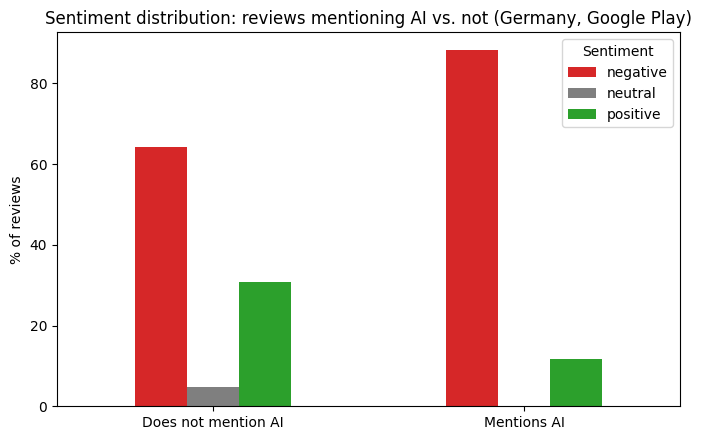

In [17]:
sentiment_pct = pd.crosstab(df["ai_mentioned"], df["sentiment"], normalize="index") * 100
sentiment_pct.index = ["Does not mention AI", "Mentions AI"]

fig, ax = plt.subplots(figsize=(7, 4.5))
sentiment_pct.plot(kind="bar", ax=ax, color=["#d62728", "#7f7f7f", "#2ca02c"])
ax.set_ylabel("% of reviews")
ax.set_title("Sentiment distribution: reviews mentioning AI vs. not (Germany, Google Play)")
ax.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs_sentiment_ai_vs_nonai.png", dpi=150)
plt.show()


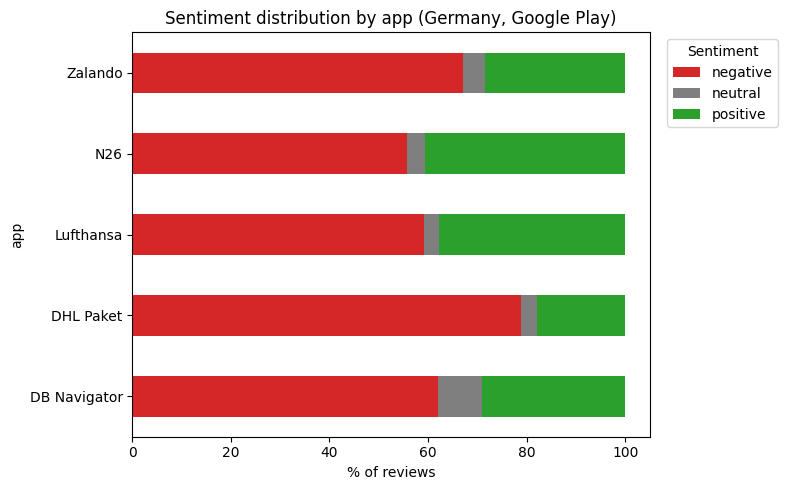

In [18]:
per_app = pd.crosstab(df["app"], df["sentiment"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 5))
per_app.plot(kind="barh", stacked=True, ax=ax, color=["#d62728", "#7f7f7f", "#2ca02c"])
ax.set_xlabel("% of reviews")
ax.set_title("Sentiment distribution by app (Germany, Google Play)")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("outputs_sentiment_by_app.png", dpi=150)
plt.show()


# **Section 8: Validity check**

The model's sentiment predictions are compared with the review star ratings. Reviews with **1–2 stars** would generally be expected to show negative sentiment, while **4–5 stars** would generally be expected to show positive sentiment. This provides a basic check of whether the model's predictions are reasonable.

sentiment    negative  neutral  positive
rating_band                             
1-2 stars        93.4      4.1       2.5
3 stars          86.9      4.1       9.0
4-5 stars        14.3      5.8      79.9


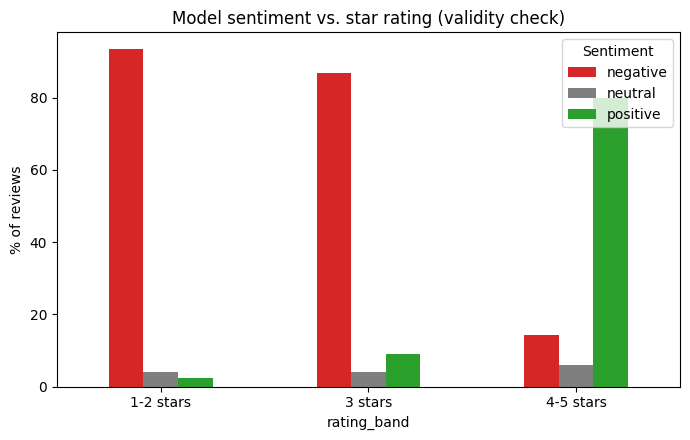

In [19]:
df["rating_band"] = pd.cut(df["star_rating"], bins=[0, 2, 3, 5], labels=["1-2 stars", "3 stars", "4-5 stars"])
validity = pd.crosstab(df["rating_band"], df["sentiment"], normalize="index") * 100
print(validity.round(1))

fig, ax = plt.subplots(figsize=(7, 4.5))
validity.plot(kind="bar", ax=ax, color=["#d62728", "#7f7f7f", "#2ca02c"])
ax.set_ylabel("% of reviews")
ax.set_title("Model sentiment vs. star rating (validity check)")
ax.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs_validity_check.png", dpi=150)
plt.show()


# **Section 9: Analyse AI-related review content**

Reviews that mention AI are separated into **positive** and **negative** groups. The most frequent words in each group are then identified after removing common German stopwords. This helps show what customers commonly discuss about AI features.



In [20]:
import collections

_STOPWORD_TEXT = (
    "der die das ein eine einer eines einem einen und oder aber auch nicht ist sind war waren "
    "sehr gut gute guter gutes fuer von mit auf in im am an zu zum zur als so wie was wenn "
    "dass man sich es er sie wir ihr mich mir dir dich uns euch ihn ihm ihnen mein meine dein "
    "deine sein seine nur noch schon immer mal hat habe haben hatte app kann konnte wurde werden"
)
GERMAN_STOPWORDS = set(_STOPWORD_TEXT.split())

def top_words(texts, n=20):
    counter = collections.Counter()
    for t in texts:
        words = re.findall(r"[a-zA-ZäöüÄÖÜß]{3,}", t.lower())
        counter.update(w for w in words if w not in GERMAN_STOPWORDS)
    return counter.most_common(n)

ai_reviews = df[df["ai_mentioned"]]
print("Top words — POSITIVE AI-related reviews:")
print(top_words(ai_reviews[ai_reviews["sentiment"] == "positive"]["text"]))

print("\nTop words — NEGATIVE AI-related reviews:")
print(top_words(ai_reviews[ai_reviews["sentiment"] == "negative"]["text"]))


Top words — POSITIVE AI-related reviews:
[('einfach', 3), ('ich', 3), ('übersichtlich', 2), ('für', 2), ('keine', 2), ('dem', 2), ('alle', 1), ('anderen', 1), ('banken', 1), ('bald', 1), ('online', 1), ('strukturiert', 1), ('alles', 1), ('funktioniert', 1), ('soll', 1), ('empfehle', 1), ('tatsächlich', 1), ('zumindest', 1), ('smart', 1), ('paket', 1)]

Top words — NEGATIVE AI-related reviews:
[('ich', 42), ('für', 13), ('konto', 11), ('keine', 10), ('wird', 9), ('mehr', 8), ('diese', 8), ('weil', 8), ('den', 7), ('über', 7), ('nach', 6), ('seit', 6), ('ohne', 6), ('wieder', 6), ('chat', 6), ('leider', 5), ('gibt', 5), ('jetzt', 5), ('dem', 5), ('dann', 5)]


# **Section 10: Save the final outputs**

The final labelled dataset, summary statistics, and three generated figures are saved to be used for **Evaluation and Results**. These files also support reproducibility and allow the analysis results to be checked.


In [21]:
summary = {
    "total_reviews_collected_raw": int(n0),
    "total_reviews_after_cleaning": int(n3),
    "reviews_mentioning_ai": int(df["ai_mentioned"].sum()),
    "pct_mentioning_ai": float(df["ai_mentioned"].mean() * 100),
    "chi2_statistic": float(chi2),
    "chi2_p_value": float(p_value),
    "apps_included": list(APPS.keys()),
    "scrape_timestamp_utc": scrape_timestamp,
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv("outputs_summary_stats.csv", index=False)
summary_df.T


,0
total_reviews_collected_raw,2000
total_reviews_after_cleaning,1647
reviews_mentioning_ai,34
pct_mentioning_ai,2.064359
chi2_statistic,8.544632
chi2_p_value,0.013949
apps_included,"[OTTO, Zalando, N26, DHL Paket, DB Navigator, Lufthansa]"
scrape_timestamp_utc,2026-09-25T09:15:33.291431+00:00
